In [1]:
import pickle
import numpy as np
import pandas as pd
import os

from nsga_population import *
from typing import List
from individual import Individual

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
log_base = "..\\logdata_2\\"
log_folders = [
    "Experiment_2_2025-02-28_15_18_40_classical",
    "Experiment_2_2025-02-28_15_18_40_classical_2",
    "Experiment_2_2025-02-19_23_23_50_random_key_main",
    "Experiment_2_2025-02-26_08_05_08_random_key_main_2",
    "Experiment_2_2025-02-20_22_19_28_hash_base",
    "Experiment_2_2025-02-26_08_05_08_hash_base_2",
    "Experiment_2_2025-02-24_09_40_06_improved_random_key",
    "Experiment_2_2025-02-25_10_04_37_improved_random_key_2"
]

In [3]:
# NB: Make sure that all experiments to be compared have run the same amount of generations
reduced_agg_columns = ["Min Makespan", "Min Mean Flow Time", "Spread", "N Non-dominated solutions"]
concat_dfs = []
for log_folder in log_folders:
    # For each log folder, create the full path
    cur_log_path = os.path.join(log_base, log_folder)
    for cur_file in os.listdir(cur_log_path):
        # For each item in the log folder, find the csv file in the root
        if cur_file[-4:] == ".csv":
            # Create the path to the csv file
            cur_csv_file_path = os.path.join(cur_log_path, cur_file)
            # Read the csv file from disc
            result_df = pd.read_csv(cur_csv_file_path, index_col=False)
            # Remove data from all iterations except the last one
            result_df = result_df[result_df["Iteration"] == result_df["Iteration"].max()].reset_index(drop=True)
            # Aggregate over the repetitions
            result_df = result_df.groupby(["Problem", "Candidate"]).agg({col_name : ["min", "max", "mean", "std", "count"] for col_name in reduced_agg_columns})
            concat_dfs.append(result_df)

convergence_df = pd.concat(concat_dfs, axis=0)
convergence_df.rename(index={"classical": "NSGA-II", "qmea_enhanced_random_key" : "srkQMEA", "quantum_hash_base_encoding" : "rQMEA", "quantum_position_encoding_restricted":"rkQMEA"}, inplace=True)
convergence_df


Min Makespan                                   \
                           min     max    mean        std count   
Problem Candidate                                                 
abz7    NSGA-II          694.0   719.0   704.8   9.186947    10   
abz8    NSGA-II          713.0   739.0   729.5   8.343327    10   
abz9    NSGA-II          737.0   767.0   757.9   9.643075    10   
ft06    NSGA-II           57.0    57.0    57.0   0.000000    10   
ft10    NSGA-II          968.0  1020.0   992.6  17.218853    10   
...                        ...     ...     ...        ...   ...   
la24    srkQMEA          988.0  1008.0   998.7   6.684144    10   
la25    srkQMEA         1034.0  1063.0  1050.2  11.272385    10   
la26    srkQMEA         1229.0  1261.0  1249.9   9.993887    10   
la27    srkQMEA         1294.0  1340.0  1315.3  12.184234    10   
la29    srkQMEA         1234.0  1270.0  1251.2  10.706177    10   

                  Min Mean Flow Time                                       \
                                 min          max         mean        std   
Problem Candidate                                                           
abz7    NSGA-II           574.500000   602.000000   591.570000   8.084010   
abz8    NSGA-II           596.350000   618.100000   607.905000   6.816502   
abz9    NSGA-II           585.450000   610.600000   593.615000   8.328133   
ft06    NSGA-II            39.666667    39.666667    39.666667   0.000000   
ft10    NSGA-II           644.800000   701.300000   681.350000  16.353474   
...                              ...          ...          ...        ...   
la24    srkQMEA           784.600000   830.066667   813.933333  14.693175   
la25    srkQMEA           797.133333   829.066667   814.533333  10.977913   
la26    srkQMEA           942.900000   983.200000   961.795000  12.271680   
la27    srkQMEA           983.550000  1012.150000  1000.165000  10.164728   
la29    srkQMEA           920.550000   976.400000   945.590000  17.843530   

                           Spread                                      \
                  count       min       max      mean       std count   
Problem Candidate                                                       
abz7    NSGA-II      10  0.951989  0.996055  0.977041  0.014080    10   
abz8    NSGA-II      10  0.932374  0.990825  0.971278  0.018843    10   
abz9    NSGA-II      10  0.882850       inf       inf       NaN    10   
ft06    NSGA-II      10  0.969855  0.969855  0.969855  0.000000    10   
ft10    NSGA-II      10  0.890523  0.984188  0.961395  0.027389    10   
...                 ...       ...       ...       ...       ...   ...   
la24    srkQMEA      10  0.902507  1.004778  0.970718  0.028472    10   
la25    srkQMEA      10  0.902831  0.985369  0.947873  0.028198    10   
la26    srkQMEA      10  0.933619  0.970023  0.950991  0.012514    10   
la27    srkQMEA      10  0.918586  0.972292  0.951743  0.014831    10   
la29    srkQMEA      10  0.881324  0.984484  0.933714  0.037095    10   

                  N Non-dominated solutions                           
                                        min max mean       std count  
Problem Candidate                                                     
abz7    NSGA-II                           2  10  5.6  2.366432    10  
abz8    NSGA-II                           3  12  6.7  2.668749    10  
abz9    NSGA-II                           1  16  6.6  4.273952    10  
ft06    NSGA-II                           2   2  2.0  0.000000    10  
ft10    NSGA-II                           3   7  4.7  1.418136    10  
...                                     ...  ..  ...       ...   ...  
la24    srkQMEA                           2  11  4.9  2.685351    10  
la25    srkQMEA                           4  11  7.4  2.547330    10  
la26    srkQMEA                           4  10  7.4  2.319004    10  
la27    srkQMEA                           4  11  8.4  2.503331    10  
la29    srkQMEA                           5  11  7.7  

In [22]:
convergence_df.columns

MultiIndex([(             'Min Makespan',   'min'),
            (             'Min Makespan',   'max'),
            (             'Min Makespan',  'mean'),
            (             'Min Makespan',   'std'),
            (             'Min Makespan', 'count'),
            (       'Min Mean Flow Time',   'min'),
            (       'Min Mean Flow Time',   'max'),
            (       'Min Mean Flow Time',  'mean'),
            (       'Min Mean Flow Time',   'std'),
            (       'Min Mean Flow Time', 'count'),
            (                   'Spread',   'min'),
            (                   'Spread',   'max'),
            (                   'Spread',  'mean'),
            (                   'Spread',   'std'),
            (                   'Spread', 'count'),
            ('N Non-dominated solutions',   'min'),
            ('N Non-dominated solutions',   'max'),
            ('N Non-dominated solutions',  'mean'),
            ('N Non-dominated solutions',   'std'),
            

In [23]:
to_latx_df = convergence_df.iloc[:, [0, 2, 3, 5, 7, 8, 16, 17, 18]]
to_latx_df = to_latx_df.astype({("Min Makespan", "min") : "int", ("Min Mean Flow Time", "min") : "int"})
to_latx_df = to_latx_df.sort_index()

In [24]:
to_latx_df.to_csv("convergence_table.csv", index=True, float_format="{:.2f}".format)

In [27]:
cur_latex_content = to_latx_df.to_latex(index=True, formatters={"Problem":str.upper}, float_format="{:.2f}".format)
with open("Latex_convergence_table.tex", "w") as latex_file:
    latex_file.write(cur_latex_content)

In [28]:
to_latx_df

Min Makespan                    Min Mean Flow Time  \
                           min    mean        std                min   
Problem Candidate                                                      
abz7    NSGA-II            694   704.8   9.186947                574   
        rQMEA              710   715.3   3.128720                591   
        rkQMEA             702   710.7   5.498485                590   
        srkQMEA            701   711.5   5.700877                591   
abz8    NSGA-II            713   729.5   8.343327                596   
...                        ...     ...        ...                ...   
la29    srkQMEA           1234  1251.2  10.706177                920   
la40    NSGA-II           1275  1292.8  11.477514               1044   
        rQMEA             1281  1301.0   9.104334               1090   
        rkQMEA            1281  1297.7   8.857514               1085   
        srkQMEA           1287  1295.2   5.493430               1071   

                                           
                          mean        std  
Problem Candidate                          
abz7    NSGA-II     591.570000   8.084010  
        rQMEA       599.945000   5.265055  
        rkQMEA      597.115000   5.303722  
        srkQMEA     599.565000   4.797977  
abz8    NSGA-II     607.905000   6.816502  
...                        ...        ...  
la29    srkQMEA     945.590000  17.843530  
la40    NSGA-II    1080.793333  13.789581  
        rQMEA      1097.406667   6.413601  
        rkQMEA     1092.446667   4.932938  
        srkQMEA    1091.940000   8.029295  

[64 rows x 6 columns]

In [29]:
to_latx_df

Min Makespan                    Min Mean Flow Time  \
                           min    mean        std                min   
Problem Candidate                                                      
abz7    NSGA-II            694   704.8   9.186947                574   
        rQMEA              710   715.3   3.128720                591   
        rkQMEA             702   710.7   5.498485                590   
        srkQMEA            701   711.5   5.700877                591   
abz8    NSGA-II            713   729.5   8.343327                596   
...                        ...     ...        ...                ...   
la29    srkQMEA           1234  1251.2  10.706177                920   
la40    NSGA-II           1275  1292.8  11.477514               1044   
        rQMEA             1281  1301.0   9.104334               1090   
        rkQMEA            1281  1297.7   8.857514               1085   
        srkQMEA           1287  1295.2   5.493430               1071   

                                           
                          mean        std  
Problem Candidate                          
abz7    NSGA-II     591.570000   8.084010  
        rQMEA       599.945000   5.265055  
        rkQMEA      597.115000   5.303722  
        srkQMEA     599.565000   4.797977  
abz8    NSGA-II     607.905000   6.816502  
...                        ...        ...  
la29    srkQMEA     945.590000  17.843530  
la40    NSGA-II    1080.793333  13.789581  
        rQMEA      1097.406667   6.413601  
        rkQMEA     1092.446667   4.932938  
        srkQMEA    1091.940000   8.029295  

[64 rows x 6 columns]

In [33]:
count_plot_df = convergence_df["N Non-dominated solutions"].reset_index()[convergence_df.reset_index()["Problem"].isin(["abz7", "abz8", "abz9", "ft10", "ft20"])]
count_plot_df.rename(columns={"mean" : "Mean number of non-dominated solutions", 
                              "max" : "Max number of non-dominated solutions", 
                              "std" : "Std number of non-dominated solutions"}, inplace=True)
count_plot_df

,Problem,Candidate,min,Max number of non-dominated solutions,Mean number of non-dominated solutions,Std number of non-dominated solutions,count
0,abz7,NSGA-II,2,10,5.6,2.366432,10
1,abz8,NSGA-II,3,12,6.7,2.668749,10
2,abz9,NSGA-II,1,16,6.6,4.273952,10
4,ft10,NSGA-II,3,7,4.7,1.418136,10
5,ft20,NSGA-II,2,8,5.4,1.955050,10
16,abz7,rkQMEA,4,9,6.9,2.233582,10
17,abz8,rkQMEA,2,9,5.1,2.330951,10
18,abz9,rkQMEA,3,11,6.2,3.011091,10
20,ft10,rkQMEA,2,9,6.0,2.260777,10
21,ft20,rkQMEA,2,8,4.4,2.270585,10


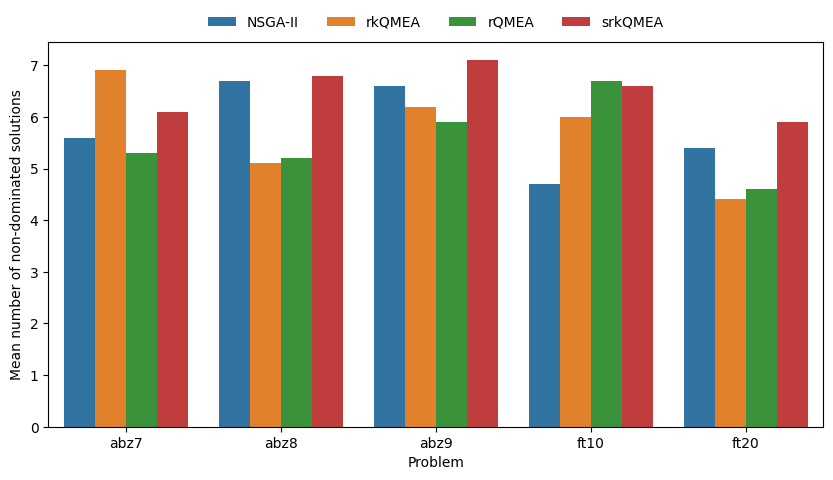

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks ft06-ft20 and abz7-abz9")
sns.barplot(data=count_plot_df, x="Problem", y="Mean number of non-dominated solutions", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

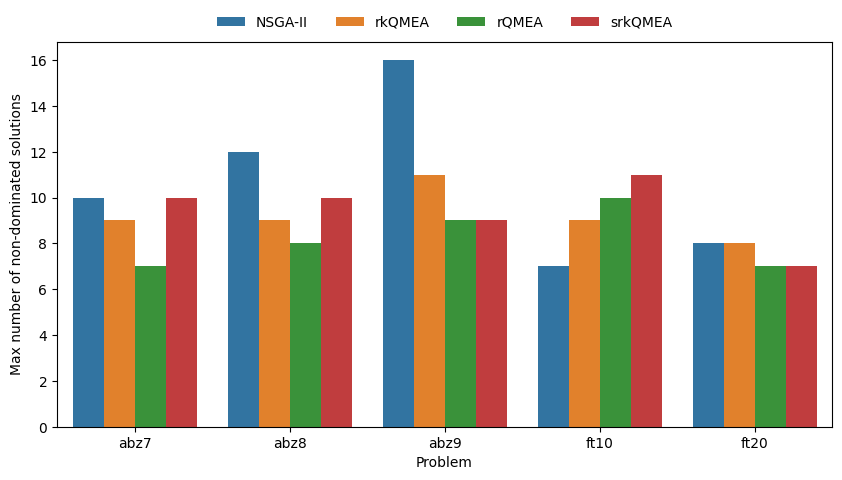

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks ft06-ft20 and abz7-abz9")
sns.barplot(data=count_plot_df, x="Problem", y="Max number of non-dominated solutions", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

In [39]:
count_plot_df = convergence_df["N Non-dominated solutions"].reset_index()[convergence_df.reset_index()["Problem"].isin(["la21", "la22", "la23", "la24", "la25", "la26", "la27", "la28", "la29","la40"])]
count_plot_df.rename(columns={"mean" : "Mean number of non-dominated solutions", 
                              "max" : "Max number of non-dominated solutions", 
                              "std" : "Std number of non-dominated solutions"}, inplace=True)
count_plot_df

,Problem,Candidate,min,Max number of non-dominated solutions,Mean number of non-dominated solutions,Std number of non-dominated solutions,count
6,la28,NSGA-II,3,8,5.8,1.873796,10
7,la40,NSGA-II,3,7,4.8,1.135292,10
8,la21,NSGA-II,2,9,4.7,2.359378,10
9,la22,NSGA-II,2,13,8.0,3.651484,10
10,la23,NSGA-II,2,10,5.8,2.699794,10
11,la24,NSGA-II,3,8,4.5,1.649916,10
12,la25,NSGA-II,4,14,9.0,3.231787,10
13,la26,NSGA-II,2,12,7.3,3.233505,10
14,la27,NSGA-II,3,11,6.4,2.633122,10
15,la29,NSGA-II,5,12,7.7,2.213594,10


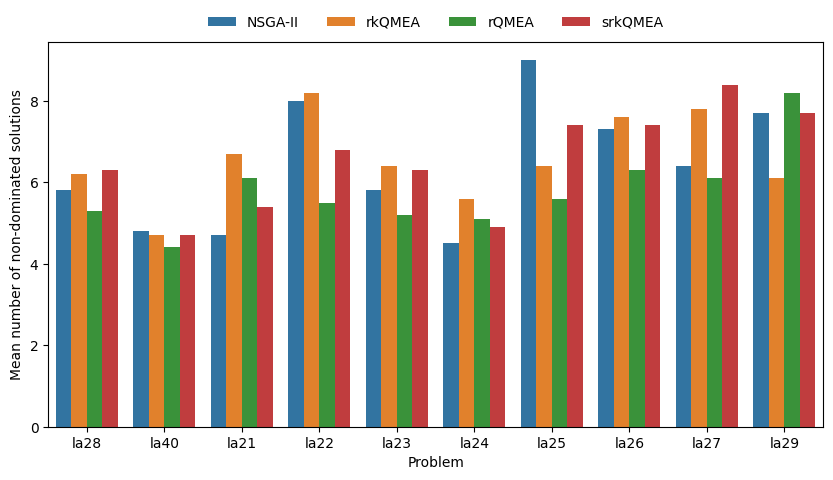

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks ft06-ft20 and abz7-abz9")
sns.barplot(data=count_plot_df, x="Problem", y="Mean number of non-dominated solutions", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

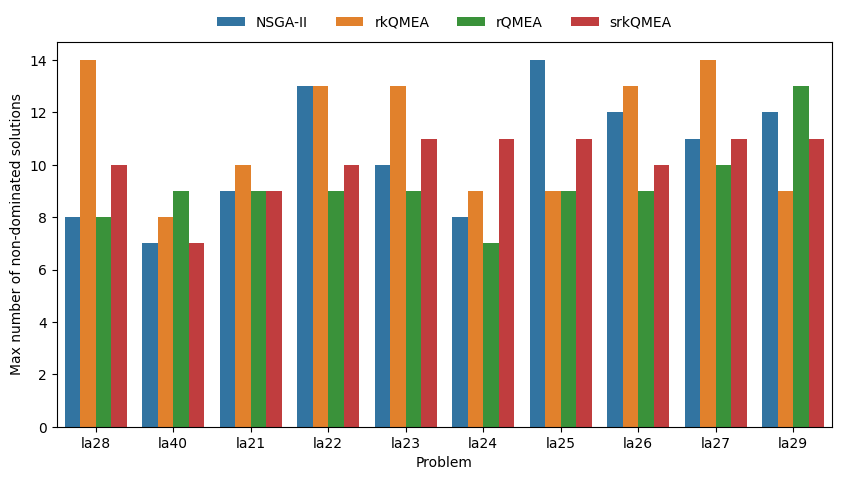

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks ft06-ft20 and abz7-abz9")
sns.barplot(data=count_plot_df, x="Problem", y="Max number of non-dominated solutions", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

Time spent per generation

In [74]:
def diff_func(x):
    return x.iloc[1] - x.iloc[0]

# NB: Make sure that all experiments to be compared have run the same amount of generations
reduced_agg_columns = ["Min Makespan", "Min Mean Flow Time", "Spread", "N Non-dominated solutions"]
concat_dfs = []
for log_folder in log_folders:
    # For each log folder, create the full path
    cur_log_path = os.path.join(log_base, log_folder)
    for cur_file in os.listdir(cur_log_path):
        # For each item in the log folder, find the csv file in the root
        if cur_file[-4:] == ".csv":
            # Create the path to the csv file
            cur_csv_file_path = os.path.join(cur_log_path, cur_file)
            # Read the csv file from disc
            result_df = pd.read_csv(cur_csv_file_path, index_col=False)
            # Aggregate over the repetitions
            result_df = result_df.groupby(["Problem", "Candidate", "Repetition"])["Time"].rolling(window=2).apply(diff_func)
            concat_dfs.append(result_df)

convergence_df = pd.concat(concat_dfs, axis=0)
convergence_df.rename(index={"classical": "NSGA-II", "qmea_enhanced_random_key" : "srkQMEA", "quantum_hash_base_encoding" : "rQMEA", "quantum_position_encoding_restricted":"rkQMEA"}, inplace=True)
convergence_df = convergence_df.reset_index()


In [75]:
convergence_df.rename(columns={"Time": "Mean time per generation"}, inplace=True)
plot_ready_df = convergence_df.groupby(["Problem", "Candidate"]).mean()

<Axes: xlabel='Problem', ylabel='Mean time per generation'>

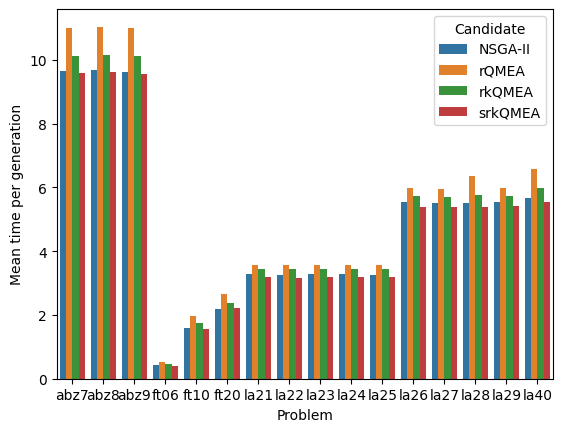

In [76]:
sns.barplot(data=plot_ready_df, x="Problem", y="Mean time per generation", hue="Candidate")

In [49]:
test.reset_index()

,Problem,Candidate,Repetition,level_3,Time
0,la21,qmea_enhanced_random_key,0,0,NaN
1,la21,qmea_enhanced_random_key,0,1,3.1867
2,la21,qmea_enhanced_random_key,0,2,3.2015
3,la21,qmea_enhanced_random_key,0,3,3.2055
4,la21,qmea_enhanced_random_key,0,4,3.1997
...,...,...,...,...,...
11995,la29,qmea_enhanced_random_key,9,11995,5.4019
11996,la29,qmea_enhanced_random_key,9,11996,5.3960
11997,la29,qmea_enhanced_random_key,9,11997,5.4308
11998,la29,qmea_enhanced_random_key,9,11998,5.4129
